# 🚀 Model Deployment – Predict Immunotherapy Response
## Hackathon DIGPHAT – PharmacogenomicDay

In this notebook you will:
1. **Load** the trained model and preprocessing artifacts saved from the Development Notebook
2. **Load** the held-out test data (unseen during training)
3. **Apply** the exact same preprocessing pipeline
4. **Generate** predictions (probabilities + binary labels)
5. **Submit** your predictions via Google Form for evaluation

In [73]:
import pandas as pd
import numpy as np
import os, joblib, warnings
warnings.filterwarnings('ignore')

print("Imports OK ✅")

Imports OK ✅


---
# 1. Load Model & Preprocessing Artifacts

All fitted objects (model, scalers, feature selector, encoders, imputer) were saved
in the Development Notebook. We load them here to ensure the **exact same**
transformations are applied to the test data.

In [74]:
artifacts = joblib.load('pipeline_artifacts.joblib')

model_name        = artifacts['model_name']
pipeline          = artifacts['pipeline']
pca               = artifacts['pca']
pca_columns       = artifacts['pca_columns']
keep_genes        = artifacts['keep_genes']
cell_cols         = artifacts['cell_cols']
pathway_cols      = artifacts['pathway_cols']
genomic_cols      = artifacts['genomic_cols']
transformers      = artifacts['transformers'] # Updated key
binary_cols       = artifacts['binary_cols']
ordinal_cols      = artifacts.get('ordinal_cols', ['MSKCC','Number_of_Prior_Therapies'])
num_cols          = artifacts.get('num_cols', ['Age'])
mice_kernel       = artifacts['kernel']
feature_columns   = artifacts['feature_columns']

print(f'✅ Loaded pipeline: {model_name}')

✅ Loaded pipeline: Logistic Regression (Optimized)


---
# 2. Load External Test Data

The test data is provided per modality in `Data/test_nivo/`.
**No labels are provided** — this is a blind evaluation.

In [75]:
# ── Load test modalities ────────────────────────────────────
test_clin = pd.read_csv('Data/test_nivo/clinical.csv')
test_dec  = pd.read_csv('Data/test_nivo/cell_deconvolution.csv')
test_ssg  = pd.read_csv('Data/test_nivo/ssgsea.csv')
test_genomic = pd.read_csv('Data/test_nivo/genomic.csv')

print("Loading transcriptomic test data...")
test_trn  = pd.read_csv('Data/test_nivo/transcriptomic.csv')

print(f"\nTest patients: {len(test_clin)}")
for name, df in [('Clinical', test_clin), ('Deconv', test_dec),
                 ('ssGSEA', test_ssg), ('Genomic', test_genomic), ('Transcriptomic', test_trn)]:
    print(f"  {name:15s} → {df.shape}")

Loading transcriptomic test data...

Test patients: 35
  Clinical        → (35, 10)
  Deconv          → (35, 27)
  ssGSEA          → (35, 51)
  Genomic         → (35, 34)
  Transcriptomic  → (35, 40935)


---
# 3. Apply Stored Preprocessing Pipeline

We reproduce the **exact same** steps from the Development Notebook,
using the **fitted** scalers, encoders, PCA, and pipeline stored in the artifacts.

| Step | Modality | Transform |
|------|----------|-----------|
| 3.1 | Transcriptomic | Filter to `keep_genes` → scale → **PCA** |
| 3.2 | ssGSEA Pathways | Scale with fitted `pathway_scaler` |
| 3.3 | Cell Deconvolution | CLR transform → scale with fitted `clr_scaler` |
| 3.4 | Clinical | Encode → MICE impute |
| 3.5 | All | Concatenate & align columns |
| 3.6 | — | Pipeline handles SelectKBest + ADASYN internally |


## 3.1 Transcriptomic Data

In [76]:
# ── 3.1  Transcriptomic preprocessing + PCA ──────────────────────────────────
test_trans = test_trn.drop('Patient_ID', axis=1).copy()

# Keep only the genes that passed variance filtering on training set
# Fill any missing genes with 0 (gene absent in test data)
missing_genes = [g for g in keep_genes if g not in test_trans.columns]
for g in missing_genes:
    test_trans[g] = 0.0
test_trans = test_trans[keep_genes]


# Apply PCA (fitted on training transcriptomics)
test_pca_result = pca.transform(test_trans)
test_pca_df = pd.DataFrame(
    test_pca_result,
    columns=pca_columns
)
print(f'After PCA → {test_pca_df.shape[1]} principal components')


After PCA → 120 principal components


## 3.2 ssGSEA Pathway Scores

In [77]:
# ── 3.2 Pathway scaling ──────────────
test_pathway = test_ssg.drop('Patient_ID', axis=1).copy()

# Align pathways to training set
for col in pathway_cols:
    if col not in test_pathway.columns:
        test_pathway[col] = 0.0
test_pathway = test_pathway[pathway_cols]

print(f"Pathways → {test_pathway.shape[1]} features (Aligned)")

Pathways → 50 features (Aligned)


## 3.3 Immune Cell Deconvolution (CLR + Scaling)

In [78]:
# ── 3.3  Immune deconvolution: CLR transform + scaling ────────────────────────
test_deconv_raw = test_dec[cell_cols].copy()

# CLR transform (same logic as training)
eps = 1e-6
X_eps = test_deconv_raw + eps
geo_mean = np.exp(np.log(X_eps).mean(axis=1))
clr_values = np.log(X_eps.div(geo_mean, axis=0))

# Scale with the fitted StandardScaler
test_deconv_clr = pd.DataFrame(
    clr_values,
    columns=cell_cols
)
print(f"Immune deconv → {test_deconv_clr.shape[1]} features")

Immune deconv → 22 features


## 3.4 Clinical Data

Encoding using the **fitted** encoders from training:
- **Categorical** (Arm) → one-hot encoding
- **Binary** (Sex, Sarc, Rhab, Tumor_Sample_Primary_or_Metastasis) → binary encoding
- **Ordinal** (MSKCC, Number_of_Prior_Therapies) → ordinal encoding
- **Numerical** (Age) → standardisation

In [79]:
# ── 3.4 Clinical preprocessing ────────────
test_clinic = test_clin.drop(columns=['Cohort', 'Arm'], errors='ignore').copy()
for col in ['Sarc', 'Rhab', 'MSKCC']:
    test_clinic[col] = test_clinic[col].replace('NO_IF', np.nan)

# ── 1. Binary Encoding ────────────
binary_encoded = test_clinic[binary_cols].copy()
for col in binary_cols:
    le = transformers[f'le_{col}']
    # Robust transform
    mask = binary_encoded[col].notna()
    vals = binary_encoded.loc[mask, col].astype(str)
    encoded = le.transform(vals)
    new_col = pd.Series(np.nan, index=binary_encoded.index, dtype=float)
    new_col.loc[mask] = encoded.astype(float)
    binary_encoded[col] = new_col

# ── 2. Ordinal Encoding (MSKCC) ───────
ordinal_encoded = test_clinic[['MSKCC']].copy()
mskcc_map = transformers['oe_MSKCC']
ordinal_encoded['MSKCC'] = ordinal_encoded['MSKCC'].map(mskcc_map)

# ── 3. Combine encoded features (Preserve Age as-is) ───
test_clinical_encoded = pd.concat([
    binary_encoded,
    ordinal_encoded,
    test_clinic[['Age', 'Number_of_Prior_Therapies']]
], axis=1)

print(f"Clinical → {test_clinical_encoded.shape[1]} features")

Clinical → 7 features


### 3.4.1 Handling Missing Values with MICE

We use the **fitted** MICE kernel from the training set to impute missing values
in the test clinical data.

In [80]:
# ── MICE imputation using fitted kernel ────────────────────────────────────────
# The MICE kernel was fitted on training data without the 'Response' column.
column_order = ['Sex', 'Age', 'MSKCC', 'Sarc', 'Rhab', 'Number_of_Prior_Therapies', 'Tumor_Sample_Primary_or_Metastasis']
missing_count = test_clinical_encoded.isna().sum().sum()
print(f"Missing values before imputation: {missing_count}")

if missing_count > 0 and mice_kernel is not None:
    test_for_mice = test_clinical_encoded.reset_index(drop=True)
    
    # Match column dtypes to the kernel's training data
    for col in mice_kernel.working_data.columns:
        if col in test_for_mice.columns:
            test_for_mice[col] = test_for_mice[col].astype(
                mice_kernel.working_data[col].dtype
            )
    test_for_mice = test_for_mice[column_order]
    test_imputed = mice_kernel.impute_new_data(test_for_mice).complete_data()
    test_clinical_imputed = test_imputed.copy()
    print(f"After MICE imputation: {test_clinical_imputed.isna().sum().sum()} missing")
elif missing_count > 0:
    test_clinical_imputed = test_clinical_encoded.fillna(test_clinical_encoded.median())
    print("Filled with median (MICE kernel not available)")
else:
    test_clinical_imputed = test_clinical_encoded.copy()
    print("No missing values – no imputation needed")

Missing values before imputation: 19
After MICE imputation: 0 missing


## 3.5 Integrate All Preprocessed Features

Combine clinical (imputed), PCA-reduced transcriptomics, pathway scores, and
deconvolution features into a single test matrix.
The column order is aligned to match the training data exactly.


In [81]:
# ── 3.3.5 Genomic Preprocessing ───────
# Same logic as My_model.ipynb
test_gen = test_genomic.set_index('Patient_ID').replace({'MUT':1, 'WT':0, 'NO_IF':np.nan}).astype(float)
test_gen['tmb_proxy'] = test_gen.sum(axis=1)
test_gen['has_genomic_data'] = (~test_gen.isna().all(axis=1)).astype(int)
test_gen_filled = test_gen.fillna(0)

# Align genomic features
for col in genomic_cols:
    if col not in test_gen_filled.columns:
        test_gen_filled[col] = 0.0
test_gen_final = test_gen_filled[genomic_cols].reset_index(drop=True)

# ── 3.5 Combine all modalities ──────────
X_test_all = pd.concat([
    test_clinical_imputed.reset_index(drop=True),
    test_pathway.reset_index(drop=True),
    test_deconv_clr.reset_index(drop=True),
    test_gen_final,
    test_pca_df.reset_index(drop=True)
], axis=1)

# Ensure all expected features are present
for col in feature_columns:
    if col not in X_test_all.columns:
        X_test_all[col] = 0.0

X_test_final = X_test_all[feature_columns]
print(f"Combined test matrix: {X_test_final.shape}")
print(f"Alignment check: {list(X_test_final.columns) == feature_columns}")

Combined test matrix: (35, 227)
Alignment check: True


## 3.6 Feature Selection & Sampling

Feature selection (SelectKBest with mutual information) and data sampling
(ADASYN) are now embedded **inside the pipeline**.
No manual feature-selection step is needed — the pipeline handles it
automatically when calling `pipeline.predict()`.


In [82]:
# Feature selection (SelectKBest) and sampling (ADASYN) are inside the pipeline.
# No manual step needed. The pipeline will handle this automatically.
print(f'Test feature matrix ready: {X_test_final.shape}')
print(f'Pipeline steps: {[step[0] for step in pipeline.steps]}')

Test feature matrix ready: (35, 227)
Pipeline steps: ['scaler', 'feature selector', 'classifier']


---
# 4. Generate Predictions

In [83]:
# ── Predict ───────────────────────────────────────────────────────────────────
# The pipeline internally applies SelectKBest and then LogisticRegression.
# Note: ADASYN (sampler) is automatically skipped during prediction.
y_pred = pipeline.predict(X_test_final)

if hasattr(pipeline, 'predict_proba'):
    y_proba = pipeline.predict_proba(X_test_final)[:, 1]
else:
    y_proba = pipeline.decision_function(X_test_final)

predictions_df = pd.DataFrame({
    'Patient_ID': test_clin['Patient_ID'].values,
    'Predicted_Response': y_pred,
    'Probability': np.round(y_proba, 4)
})
display(predictions_df)

print(f'\nPredicted Responders:     {int(y_pred.sum())} / {len(y_pred)}')
print(f'Predicted Non-Responders: {int((1 - y_pred).sum())} / {len(y_pred)}')


,Patient_ID,Predicted_Response,Probability
0,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,1,1.0000
1,G138701_RCCBMS-00099-T_v1_RNA_OnPrem,1,0.9991
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,1,0.9989
3,G109543_RCCBMS-00007-T_v1_RNA_OnPrem,1,0.6420
4,G138701_RCCBMS-00093-T_v1_RNA_OnPrem,1,0.9985
5,G138701_RCCBMS-00028-T_v1_RNA_OnPrem,1,0.9998
6,G138701_RCCBMS-00125-T_v1_RNA_OnPrem,1,0.7166
7,G138701_RCCBMS-00165-T_v1_RNA_OnPrem,1,0.6737
8,G138701_RCCBMS-00036-T_v1_RNA_OnPrem,1,0.9998
9,G138701_RCCBMS-00103-T_v1_RNA_OnPrem,0,0.4104



Predicted Responders:     31 / 35
Predicted Non-Responders: 4 / 35


In [84]:
y_true_df = pd.read_csv('Data/test_nivo/test_labels.csv')
y_true = y_true_df['Response'].to_list()  

In [85]:
#Calculate metrics

from sklearn.metrics import roc_auc_score, f1_score, average_precision_score

roc = roc_auc_score(y_true, y_proba)
f1 = f1_score(y_true, y_pred)
ap = average_precision_score(y_true, y_proba)

print(f"ROC AUC: {roc}")
print(f"F1 Score: {f1}")
print(f"Average Precision: {ap}")

ROC AUC: 0.4444444444444444
F1 Score: 0.358974358974359
Average Precision: 0.33588230235531585


---
# 5. Model Interpretation (SHAP)

Which features are driving the predictions? We use **SHAP (SHapley Additive exPlanations)** 
 to break down the model's logic.

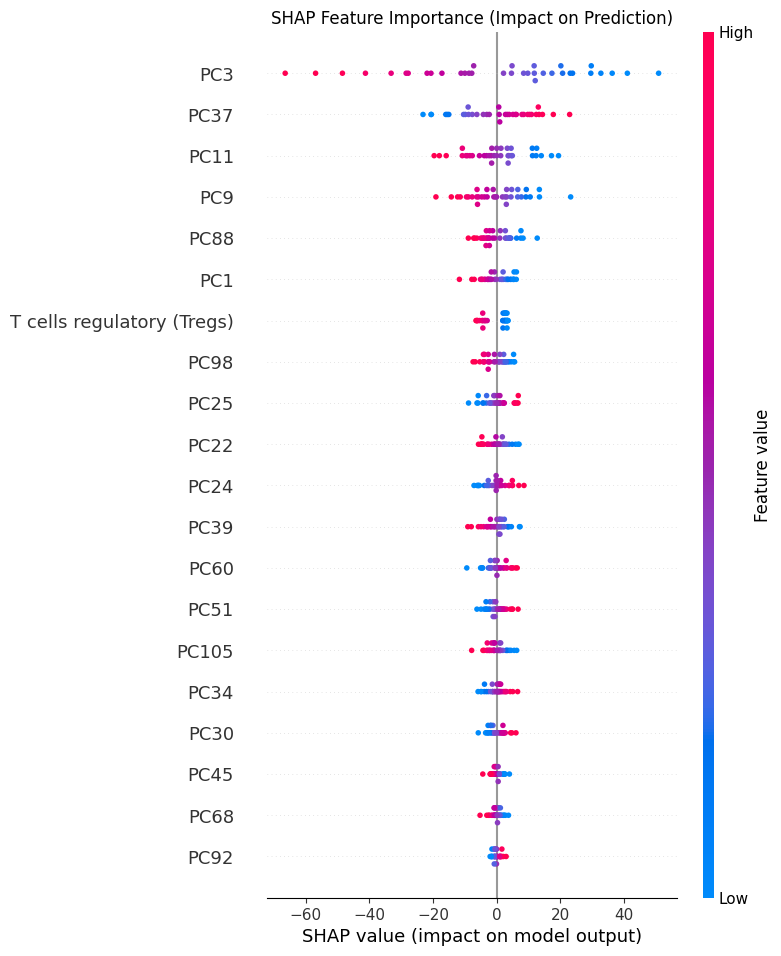

In [86]:
import shap
import matplotlib.pyplot as plt

# 1. Extract the classifier and feature selector from the pipeline
clf = pipeline.named_steps['classifier']
selector = pipeline.named_steps['feature selector']

# 2. Transform the test data using the selector (matching the model input)
X_test_sel = selector.transform(X_test_final)
mask = selector.get_support()
selected_features = X_test_final.columns[mask]

# 3. Compute SHAP values
explainer = shap.LinearExplainer(clf, selector.transform(X_test_final))
shap_values = explainer.shap_values(X_test_sel)

# 4. Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, feature_names=selected_features, show=False)
plt.title("SHAP Feature Importance (Impact on Prediction)")
plt.show()

---
# 6. Performance Report (Hidden Evaluation)

Your predictions will now be evaluated against the hidden ground truth using the instructor's evaluator script.

In [87]:
import evaluator

# Prepare predictions for the evaluator
# The evaluator expects columns: ['Patient_ID', 'Prediction', 'Probability']
eval_df = predictions_df.rename(columns={'Predicted_Response': 'Prediction'})

results = evaluator.evaluate(eval_df)

ImportError: bad magic number in 'evaluator': b'\xa7\r\r\n'

---
# 7. Submit Predictions via Google Form

Push your team's predictions directly from this notebook.


In [ ]:
import requests
TEAM_NAME      = "YOUR_TEAM_NAME" 
FORM_URL       = "https://docs.google.com/forms/d/e/YOUR_FORM_ID/formResponse"
ENTRY_TEAM     = "entry.XXXXXXXXX"
ENTRY_PREDS    = "entry.YYYYYYYYY"

pred_string = ",".join(map(str, y_pred.tolist()))
payload = {ENTRY_TEAM: TEAM_NAME, ENTRY_PREDS: pred_string}
response = requests.post(FORM_URL, data=payload)
if response.status_code == 200: print("✅ Submitted!")
else: print("❌ Failed")